In [440]:
# Libraries
# scipy, numpy, pandas, matplotlib, seaborn and scikit-learn

from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# parameter tuning
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, roc_auc_score

# Additional libraries

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# SVM 
from sklearn import svm
from sklearn.svm import SVC

# KNN
from sklearn.neighbors import KNeighborsClassifier

#nb
from sklearn.naive_bayes import GaussianNB

In [441]:
data =  '1_marketing_analysis_Classification.csv'

In [442]:
df = pd.read_csv(data)
df = df.drop("duration", axis = 1)
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,2,-1,0,unknown,yes


In [443]:
y_values = df['deposit']
X_ = df.drop(columns=['deposit'])

y_values = y_values.map({'yes': 1, 'no': 0})
X_values = pd.get_dummies(X_, drop_first=True)

df.shape

(11162, 16)

In [444]:


class DataPrep:
    def __init__(self, test_size = 0.20, validation_size = 0.20, random_state = 123):
        self.test_size = test_size
        self.validation_size = validation_size
        self.random_state = random_state

        self.scaler = StandardScaler()

        self.X_train, self.X_test, self.X_val = None, None, None
        self.y_train, self.y_test, self.y_val = None, None, None
        self.X_train_scaled, self.X_test_scaled, self.X_val_scaled = None, None, None
        self.X_combined, self.X_combined_scaled, self.y_combined = None, None, None
 
    def split(self, X_values, y_values):
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(X_values, 
                                                                    y_values, 
                                                                    test_size = self.test_size, 
                                                                    random_state=self.random_state)
        adj_val_size = self.validation_size / (1.0 - self.test_size)
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(X_temp,
                                                                              y_temp,
                                                                              test_size=adj_val_size,
                                                                              random_state=self.random_state)
        return self

    def transform(self):
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)
        self.X_val_scaled = self.scaler.transform(self.X_val)
        return self

    def combine(self):
        # Combines unscaled training and validation data
        self.X_combined = np.vstack([self.X_train, self.X_val])
        self.y_combined = np.concatenate([self.y_train, self.y_val])
        return self

    def combine_scaled(self):
        # Combines scaled training and validation data
        self.X_combined_scaled = np.vstack([self.X_train_scaled, self.X_val_scaled])
        self.y_combined = np.concatenate([self.y_train, self.y_val])
        return self



In [445]:

data = DataPrep(test_size=0.20, validation_size=0.20, random_state=123)
data.split(X_values, y_values)
data.transform()
data.combine()
data.combine_scaled()

print('Training data:', data.X_train.shape)



Training data: (6696, 41)


### Exploratory Data Analysis

In [446]:
data.X_train.describe()

,age,balance,day,campaign,pdays,previous
count,6696.000000,6696.000000,6696.000000,6696.000000,6696.000000,6696.000000
mean,41.260155,1528.874552,15.753136,2.525538,48.864397,0.802867
std,11.962680,3317.929471,8.419056,2.734496,105.360699,2.181934
min,18.000000,-3058.000000,1.000000,1.000000,-1.000000,0.000000
25%,32.000000,121.000000,8.000000,1.000000,-1.000000,0.000000
50%,39.000000,535.500000,15.500000,2.000000,-1.000000,0.000000
75%,49.000000,1693.000000,22.000000,3.000000,-1.000000,0.000000
max,93.000000,81204.000000,31.000000,63.000000,854.000000,55.000000


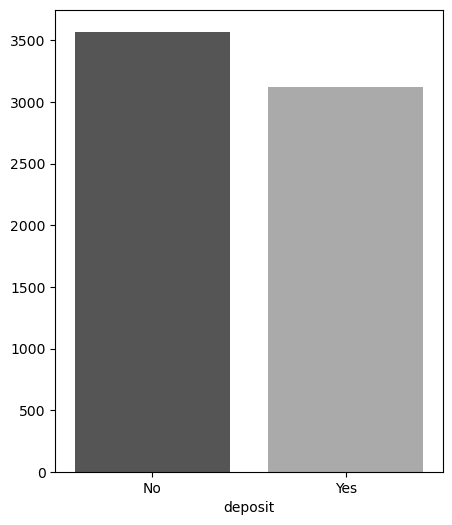

In [447]:
plt.figure(figsize=(5, 6))


sns.countplot(
    x=data.y_train,      
    hue=data.y_train,     
    palette='grey',
    legend=False
)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.ylabel("")
plt.show()


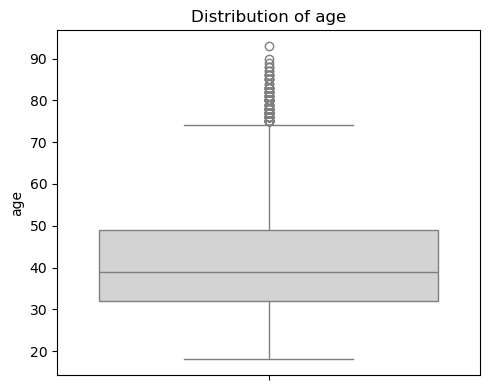

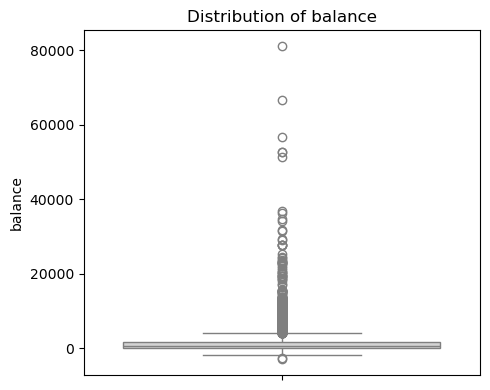

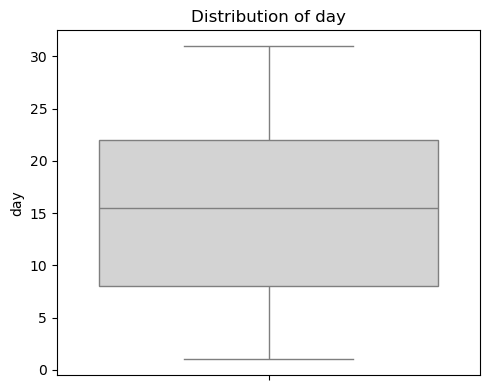

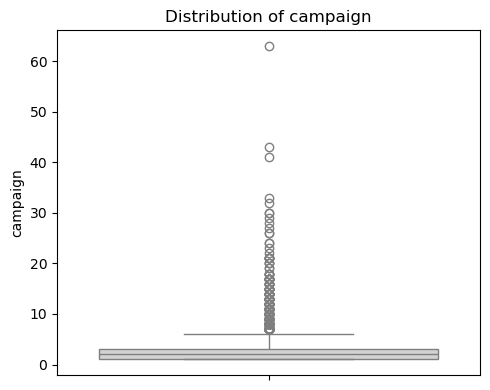

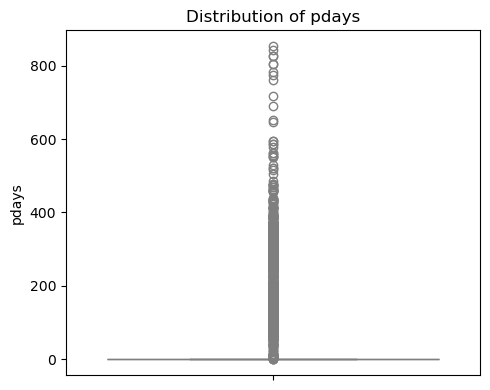

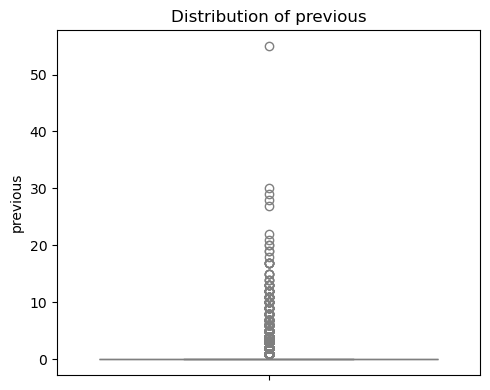

In [448]:
numeric_columns = data.X_train.select_dtypes(include=[np.number]).columns
numeric_columns


for i,feature_name in enumerate(numeric_columns):
    plt.figure(figsize=(5, 4))
    sns.boxplot(data.X_train,
                y= feature_name, 
                color = 'lightgrey')
    plt.title(f"Distribution of {feature_name}")
    plt.tight_layout()
    plt.show()      
    

In [449]:
# removing outliers

Q1 = data.X_train[numeric_columns].quantile(.25)
Q3 = data.X_train[numeric_columns].quantile(.75)
IQR = Q3-Q1

lower_bound = Q1 - (1.5*IQR)
upper_bound = Q3 + (1.5*IQR)
train_outliers = ((data.X_train[numeric_columns] < lower_bound) | (data.X_train[numeric_columns] > upper_bound)).any(axis=1)


print('Outliers in dataset:', data.X_train[train_outliers].shape)



Outliers in dataset: (2462, 41)


In [450]:
data.X_train = data.X_train[~train_outliers]
data.y_train = data.y_train[~train_outliers]

print('After removing outliers: ', data.X_train.shape)

After removing outliers:  (4234, 41)


In [451]:
data.transform()
data.combine()
data.combine_scaled()

print("Cleaned & Scaled Train Set Shape:", data.X_train_scaled.shape)
print("Cleaned Combined (Train+Val) Shape:", data.X_combined_scaled.shape)

Cleaned & Scaled Train Set Shape: (4234, 41)
Cleaned Combined (Train+Val) Shape: (6467, 41)


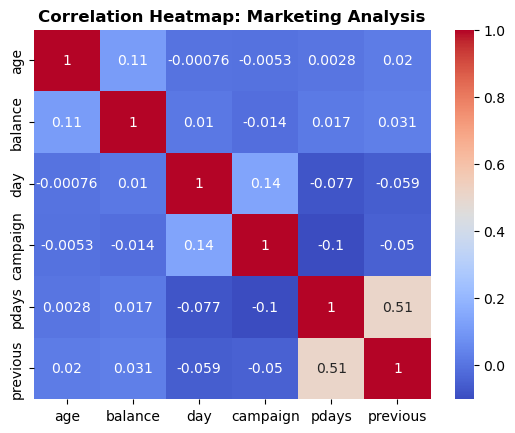

In [452]:
# correlation heatmap

correlation_matrix = df.corr(numeric_only = True)
sns.heatmap(correlation_matrix, cmap= "coolwarm", annot= True)
plt.title("Correlation Heatmap: Marketing Analysis", fontsize=12, fontweight='bold')
plt.show()

In [453]:
# PredefinedSplit to use validation set in grid search

def val_split_idxs(X_train, X_combined):
    split_index = np.zeros(X_combined.shape[0]) 
    split_index[:len(X_train)] = -1           
    split_index[len(X_train):] = 0 # Mark validation samples with 0
    return PredefinedSplit(test_fold=split_index)

pds = val_split_idxs(data.X_train, data.X_combined)

### Models

#### Decison Trees

In [454]:

dt_m = DecisionTreeClassifier(max_depth = 3, 
                              criterion='gini', 
                              random_state=123)
dt_m.fit(data.X_train, data.y_train)
val_preds = dt_m.predict(data.X_val)
val_accuracy = accuracy_score(data.y_val, val_preds) 

print(f"Decision Tree Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")

# parameter grid for decision tree
dt_param = {
    'max_depth': [1, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 3, 5]
}
metrics = ['accuracy', 'f1']
# GridSearchCV using with predefined split for decision tree
dt_search = GridSearchCV(
    estimator=dt_m,
    param_grid=dt_param,
    cv=pds,
    scoring= metrics,
    refit= "accuracy",
    n_jobs=-1
)

# Fit on the combined dataset
dt_search.fit(data.X_combined, data.y_combined)

# Output results
print(f"Best Parameters: {dt_search.best_params_}")
print(f"Best Validation Score: {dt_search.best_score_*100:.4f}")



Decision Tree Baseline Validation Accuracy: 64.7559%
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best Validation Score: 65.5620


In [455]:
importances = pd.Series(dt_m.feature_importances_, 
                        index = data.X_train.columns)
importances.sort_values(ascending = False).head(5)

contact_unknown    0.536406
balance            0.191982
housing_yes        0.148542
age                0.064264
marital_married    0.025515
dtype: float64

#### Random Forest

In [456]:
rf_m = RandomForestClassifier(criterion='gini', n_estimators = 100, random_state=123)
rf_m.fit(data.X_train, 
         data.y_train)
val_preds = rf_m.predict(data.X_val)
val_accuracy = accuracy_score(data.y_val, val_preds)

print(f"Random Forest Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")

# parameter grid for random forest
rf_param = {
    'max_depth': [1, 5, 10, 20],
    'min_samples_split': [2, 3, 4, 5], 
    'n_estimators' : [100, 200, 300]
}
metrics = ['accuracy', 'f1']
# GridSearchCV using with predefined split for random forest
rf_search = GridSearchCV(
    estimator=rf_m,
    param_grid=rf_param,
    cv=pds,
    scoring=metrics,
    refit = 'accuracy',
    n_jobs=-1
)

# Fit on the combined dataset
rf_search.fit(data.X_combined, data.y_combined)

# Output results
print(f"Best Parameters: {rf_search.best_params_}")
print(f"Best Validation Score: {rf_search.best_score_*100:.4f}")

Random Forest Baseline Validation Accuracy: 69.3686%
Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best Validation Score: 69.7268


#### Support Vector Machine

In [457]:
data.split(X_values, y_values)
data.transform()
data.combine()
data.combine_scaled()


svm_m = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=123, probability = True)

svm_m.fit(data.X_train_scaled, data.y_train)

val_preds = svm_m.predict(data.X_val_scaled)
val_accuracy = accuracy_score(data.y_val, val_preds)

print(f"SVM Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")

# SVM - Hyper parameter tuning

svm_param = [{'kernel': ['linear'], 'C': [0.1, 1.0, 10]},
             {'kernel': ['rbf'],'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 'auto', 0.01, 0.1] }]
# scale and auto are sensitive to feature number and variance

metrics = ['accuracy', 'f1']
svm_search = GridSearchCV(
    estimator=svm_m, 
    param_grid=svm_param, 
    cv=pds, 
    scoring=metrics,
    refit = 'accuracy',
    n_jobs=-1
)

svm_search.fit(data.X_combined_scaled, data.y_combined)
print(f"Best Hyperparameters: {svm_search.best_params_}")
print(f"Best Validation Accuracy: {svm_search.best_score_ * 100:.4f}%")

SVM Baseline Validation Accuracy: 72.3690%
Best Hyperparameters: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best Validation Accuracy: 72.3690%


#### K-Nearest Neighbors

In [458]:
# K-Nearest Neigbhors

knn_m = KNeighborsClassifier(n_neighbors=5)
knn_m.fit(data.X_train_scaled, data.y_train)
val_preds = knn_m.predict(data.X_val_scaled)
val_accuracy = accuracy_score(data.y_val, val_preds)

print(f"KNN Baseline Validation Accuracy: {val_accuracy * 100:.4f}%")

knn_param = [{
    'n_neighbors': [3, 4, 5], 
    'metric': ['euclidean']
}]

metrics = ['accuracy', 'f1']
knn_search = GridSearchCV(
    estimator=knn_m, 
    param_grid=knn_param, 
    cv=pds, # Evaluates hyperparams using your scaled validation rows
    scoring=metrics,
    refit= 'accuracy',
    n_jobs=-1
)

knn_search.fit(data.X_combined_scaled, data.y_combined)
print(f"Best Hyperparameters: {knn_search.best_params_}")
print(f"Best Validation Accuracy: {knn_search.best_score_ * 100:.4f}%")

KNN Baseline Validation Accuracy: 67.7116%
Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 5}
Best Validation Accuracy: 68.4729%


#### Naive Bayes

In [459]:
nb_m = GaussianNB()
nb_m.fit(data.X_train, data.y_train)
nb_val_preds = nb_m.predict(data.X_val)
nb_val_accuracy = accuracy_score(data.y_val, nb_val_preds)

print(f"Naive Bayes Baseline Validation Accuracy: {nb_val_accuracy * 100:.4f}%")

# smoothing points
nb_param = {"var_smoothing": np.logspace(0, -9, num = 100)}

metrics = ["accuracy", "f1_macro"]

nb_search = GridSearchCV(
    estimator=nb_m,
    param_grid=nb_param,
    cv=pds,
    scoring= metrics,
    refit="accuracy",
    n_jobs=-1,
)

nb_search.fit(data.X_combined, data.y_combined)

print(f"Best Parameters: {nb_search.best_params_}")
print(f"Best Validation Score: {nb_search.best_score_ * 100:.4f}%")


Naive Bayes Baseline Validation Accuracy: 67.4877%
Best Parameters: {'var_smoothing': np.float64(1e-09)}
Best Validation Score: 68.4729%


### Model Evaluation

In [460]:
# Decision Tree - final evaluation

final_dt = dt_search.best_estimator_

dt_test_preds = final_dt.predict(data.X_test.values)

dt_report = classification_report(data.y_test, dt_test_preds)


# confusion matrix
dt_cm = confusion_matrix(data.y_test, dt_test_preds)

In [461]:
# Random Forest - final evaluation

final_rf = rf_search.best_estimator_
rf_test_preds = final_rf.predict(data.X_test.values)
rf_report=classification_report(data.y_test, rf_test_preds)


# confusion matrix
rf_cm = confusion_matrix(data.y_test, rf_test_preds)

In [462]:
# SVM - final evaluation



final_svm = svm_search.best_estimator_

svm_test_preds = final_svm.predict(data.X_test_scaled)

svm_report = classification_report(data.y_test, svm_test_preds)

# confusion matrix
svm_cm = confusion_matrix(data.y_test, svm_test_preds)


In [463]:
# KNN - final evaluation



final_knn = knn_search.best_estimator_

knn_test_preds = final_knn.predict(data.X_test_scaled)
knn_report = classification_report(data.y_test, knn_test_preds)

# confusion matrix
knn_cm = confusion_matrix(data.y_test, knn_test_preds)


In [464]:
# NB - final evaluation


final_nb = nb_search.best_estimator_

nb_test_preds = final_nb.predict(data.X_test_scaled)
nb_report = classification_report(data.y_test, knn_test_preds)

# confusion matrix
nb_cm = confusion_matrix(data.y_test, knn_test_preds)

#### Confusion Matrices

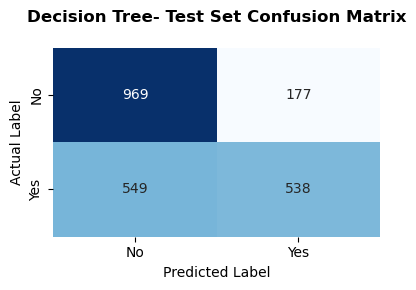

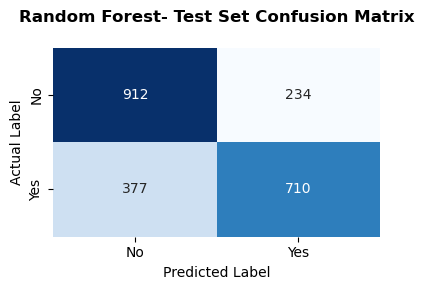

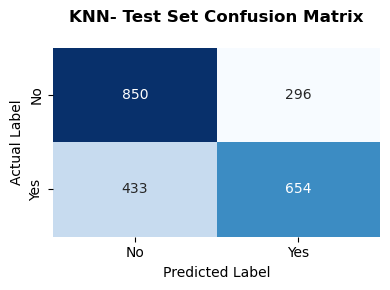

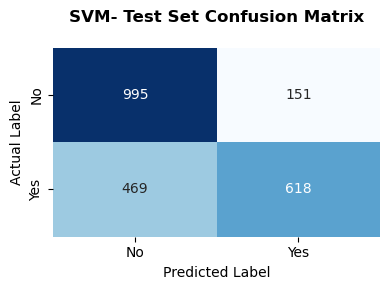

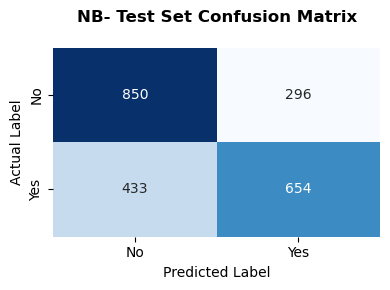

In [465]:
cm_objects = {
    'Decision Tree': dt_cm, 
    'Random Forest': rf_cm, 
    'KNN': knn_cm, 
    'SVM': svm_cm,
    'NB': nb_cm 
}

class_labels = ['No', 'Yes']

for model_name, cm_obj in cm_objects.items():
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_obj, 
                annot=True, 
                fmt='d', 
                cmap='Blues', 
                cbar=False,
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.title(f"{model_name}- Test Set Confusion Matrix\n", fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.tight_layout()
    plt.show()
    print("\n")

#### Model Hyperparameters

In [466]:
model_objects = {
    'Decision Tree': final_dt, 
    'Random Forest': final_rf, 
    'KNN': final_knn, 
    'SVM': final_svm,
    'NB': final_nb 
}

model_params = []

for model_name, model_obj in model_objects.items():
    print(model_name, '\n')
    params = model_obj.get_params()
    print(params, '\n')
    model_params.append({
        "Model": model_name,
        "All Parameters": params
    })
df_model_params = pd.DataFrame(model_params)

Decision Tree 

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'} 

Random Forest 

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False} 

KNN 

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'} 

SVM 

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, '

#### Model Performance

In [467]:

preds_objects = {
    'Decision Tree': dt_test_preds, 
    'Random Forest': rf_test_preds, 
    'KNN': knn_test_preds, 
    'SVM': svm_test_preds,
    'NB' : nb_test_preds
}

model_metrics = []
class_labels = ['No', 'Yes'] # Maps 0 (no) and 1 (yes) bank deposit states

for model_name, pred_objs in preds_objects.items():
    print(f"\nModel: {model_name} - Final Evaluation\n")
    
    text_report = classification_report(data.y_test, 
                                        pred_objs, 
                                        target_names=class_labels)
    print(text_report)
    
    report_dict = classification_report(data.y_test, 
                                        pred_objs, 
                                        output_dict=True, 
                                        target_names=class_labels)
    
    model_metrics.append({
        "Model": model_name,
        "Accuracy": f"{report_dict['accuracy']*100:.2f}%",
        "Precision (Macro)": f"{report_dict['macro avg']['precision']*100:.2f}%",
        "Recall (Macro)": f"{report_dict['macro avg']['recall']*100:.2f}%",
        "F1-Score (Macro)": f"{report_dict['macro avg']['f1-score']*100:.2f}%"
    })

df_model_metrics = pd.DataFrame(model_metrics)
print("\nOverall Model Comparison")
print(df_model_metrics.to_string(index=False))

# dt correctly predicts 71% of all data



Model: Decision Tree - Final Evaluation

              precision    recall  f1-score   support

          No       0.64      0.85      0.73      1146
         Yes       0.75      0.49      0.60      1087

    accuracy                           0.67      2233
   macro avg       0.70      0.67      0.66      2233
weighted avg       0.69      0.67      0.66      2233


Model: Random Forest - Final Evaluation

              precision    recall  f1-score   support

          No       0.71      0.80      0.75      1146
         Yes       0.75      0.65      0.70      1087

    accuracy                           0.73      2233
   macro avg       0.73      0.72      0.72      2233
weighted avg       0.73      0.73      0.72      2233


Model: KNN - Final Evaluation

              precision    recall  f1-score   support

          No       0.66      0.74      0.70      1146
         Yes       0.69      0.60      0.64      1087

    accuracy                           0.67      2233
   macro avg

#### ROC-AUC Curve

C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


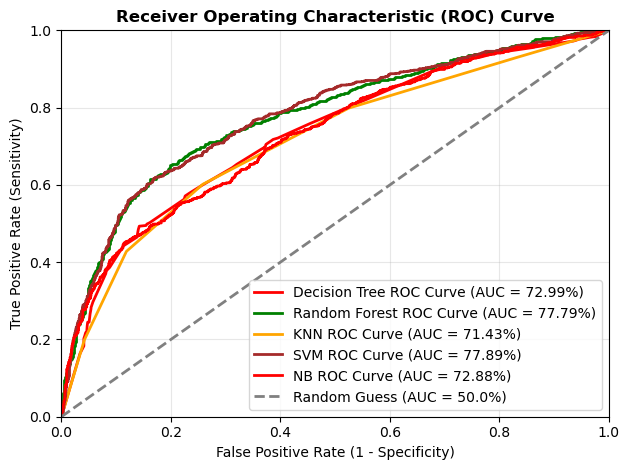

In [468]:
model_objects = {
    'Decision Tree': final_dt, 
    'Random Forest': final_rf, 
    'KNN': final_knn, 
    'SVM': final_svm,
    'NB': final_nb
}

colors = {
    'Decision Tree': "red", # Blue
    'Random Forest': "green", # Green
    'KNN': "orange", # Orange
    'SVM': "brown", # Purple
    'NB': "red" # Red
}

for model_name, model_obj in model_objects.items():
    X_test_transform = data.X_test_scaled if model_name in ['KNN', 'SVM'] else data.X_test
    y_probs = model_obj.predict_proba(X_test_transform)[:,1]
    
    # plot curve
    fpr, tpr, thresholds = roc_curve(data.y_test, y_probs)
    auc = roc_auc_score(data.y_test, y_probs)
    plt.plot(fpr, 
             tpr, 
             color= colors[model_name], 
             lw=2, 
             label= f'{model_name} ROC Curve (AUC = {auc * 100:.2f}%)')

plt.plot([0,1], [0,1], color = 'grey', lw=2, linestyle = '--', label= 'Random Guess (AUC = 50.0%)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Summary

#### The model has been optimized by tuning the hyper parameters of several machine learning algorithms to identify the best model evaluated across key metrics. By tuning model hyper parameters, baseline validation accuracy increased by optimization of hyper parameters (67.71% to 69.72%).  The optimized model is built on 300 decision trees, at most 20 splits nodes, and will stop splitting if a node has less than 5 samples remaining.  The model shows no evidence of overfitting, as model performance improved tp 73.0% accuracy when evaluated on new test data.  The model demonstrates strong performance with a 75.0% precision rate when predicting positive cases, while maintaining a 65.0% recall rate for successfully capturing positive cases.  The model demonstrates a highly robust ROC curve with an AUC score of 77.78%, indicating a classification performance that significantly outperforms a random guess.